In [74]:
import influxdb_client
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import pytz
import os
import csv

In [75]:
def find_daytime(arr):
    #find start of day
    for i, element in enumerate(arr):
        if element > 0.1/1800:
            start = i
            break
    #find end of day
    for i, element in enumerate(arr[::-1]):
        if element >= 0.1/1800:
            end = len(arr)-i
            break
    return start, end

array = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.5,0,1,2,3,4,5,6,7,8,9,10,11,12,13,0,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
start, end = find_daytime(array)
print(array[start:end])

[0.5, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 0, 14]


In [76]:
def lux_to_wm2(lux_array):
    """
    Umrechnung von Lux zu W/m² für Sonnenlicht.
    1 W/m² ≈ 125 Lux (für Sonnenlicht, grobe Faustformel) https://www.landwirtschaftskammer.de/gartenbau/beratung/technik/artikel/lichtwerte-umrechnen.htm
    """
    return np.array(lux_array) / 125


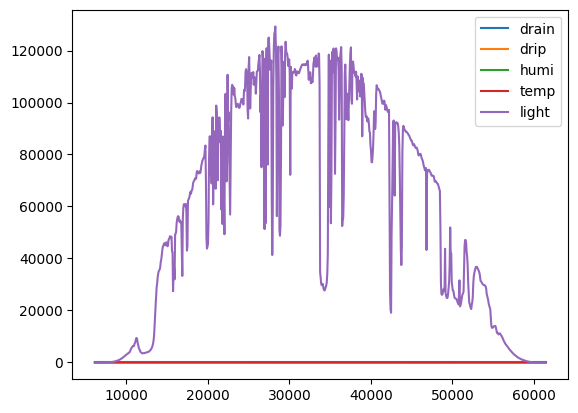

In [77]:
def get_data(nodeId, start, stop):
  #set influxDB access
  token = "tpvr6ve_kbZqMH1YypOEY17Bkz6dF7ccxd_pycGUmOsPowCMHTQvNzPKBhdoPFKddZY4yJgEdt49Bu4Lo-5NmA=="
  org = "home"
  url = "http://192.168.8.15:8086"
  client = influxdb_client.InfluxDBClient(url=url, token=token, org=org)
  query_api = client.query_api()

  #set timezone
  local_tz = pytz.timezone('Europe/Berlin')
  start = local_tz.localize(start)
  stop = local_tz.localize(stop)

  #create queries
  labels = {
      "drain":  {"query": '|> filter(fn: (r) => r["_measurement"] == "nodeID")|> filter(fn: (r) => r["_field"] == "volume")|> filter(fn: (r) => r["channel"] == "4")'},
      "drip":   {"query": '|> filter(fn: (r) => r["_measurement"] == "nodeID")|> filter(fn: (r) => r["_field"] == "volume")|> filter(fn: (r) => r["channel"] == "3")'},
      "humi":   {"query": '|> filter(fn: (r) => r["_measurement"] == "nodeID")|> filter(fn: (r) => r["_field"] == "humidity")'},
      "temp":   {"query": '|> filter(fn: (r) => r["_measurement"] == "nodeID")|> filter(fn: (r) => r["_field"] == "temperature")'},
      "light":  {"query": '|> filter(fn: (r) => r["_measurement"] == "2CF7F1C0449000CD")|> filter(fn: (r) => r["_field"] == "light_intensity")'},
  }

  for label in labels:
    genericFluxQuery = 'from(bucket: "SensorNodes")|> range(start: startTime, stop: stopTime)' + labels[label]["query"]
    genericFluxQuery = genericFluxQuery.replace("startTime",start.isoformat())  #replace start time
    genericFluxQuery = genericFluxQuery.replace("stopTime",stop.isoformat())    #replace stop time
    genericFluxQuery = genericFluxQuery.replace("nodeID", nodeId)               #replace nodID

    tables = query_api.query(genericFluxQuery, org=org)
    x_time = []
    y_value = []

    for table in tables:
      for record in table.records:
        time = record["_time"] - start
        x_time.append(time.total_seconds())
        y_value.append(record["_value"])

    #interpolate if it not fits the drain measurment
    if label != "drain":
      labels[label]["value"] = np.interp(labels["drain"]["time"],x_time,y_value)
      labels[label]["time"] = labels["drain"]["time"]
    else:
      labels[label]["value"] = y_value
      labels[label]["time"] = x_time

  #cut labeled data to daytime
  start, stop = find_daytime(labels["light"]["value"])
  for label in labels:
    labels[label]["value"] = labels[label]["value"][start:stop]
    labels[label]["time"] = labels[label]["time"][start:stop]
  return labels

#Test
labels = get_data("70B3D57ED005C6D0", datetime(2023, 8, 23, 4), datetime(2023, 8, 23, 23))
for label in labels:
  plt.plot(labels[label]["time"],labels[label]["value"],label=label)
plt.legend()
plt.show()

Original data length: 865
Downsampled data length: 86


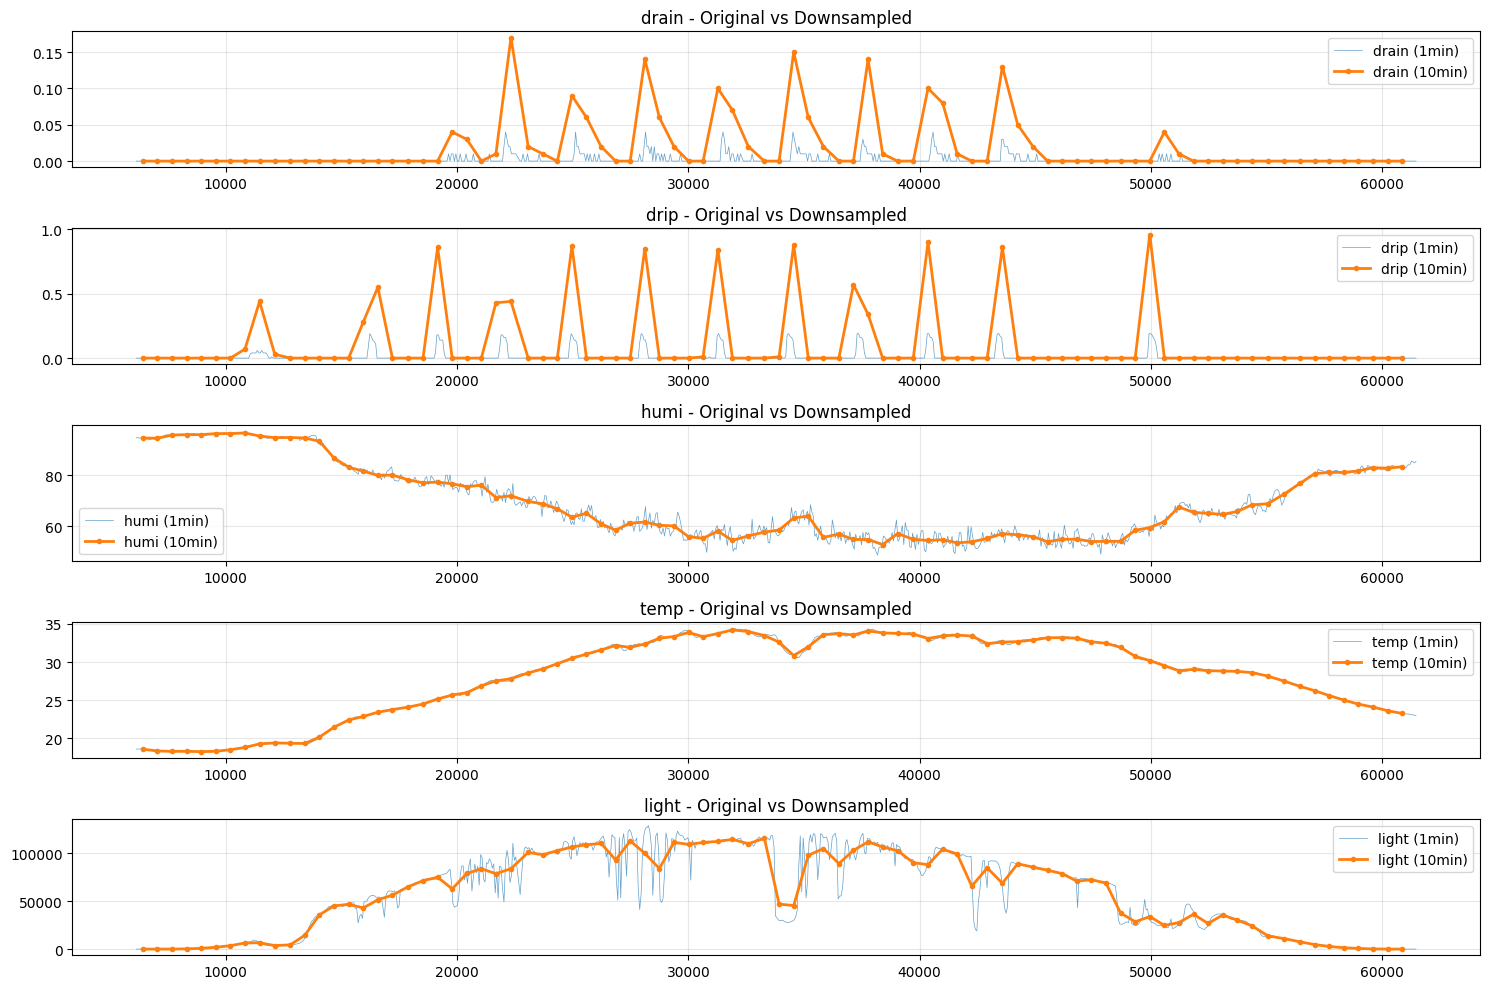

In [78]:
def downsample_labeled_data(labeledData, factor=10):
    """
    Downsample labeledData from 1min to factor*1min intervals
    
    Args:
        labeledData: Dictionary with sensor data
        factor: Downsampling factor (default=10 for 10min intervals)
    
    Returns:
        Downsampled labeledData dictionary
    """
    downsampled_data = {}
    
    for label in labeledData:
        values = np.array(labeledData[label]["value"])
        times = np.array(labeledData[label]["time"])
        
        # Calculate number of complete intervals
        n_intervals = len(values) // factor
        
        if n_intervals == 0:
            # If data is shorter than one interval, keep original
            downsampled_data[label] = {
                "value": values,
                "time": times
            }
            continue
            
        # Reshape and aggregate data
        reshaped_values = values[:n_intervals * factor].reshape(n_intervals, factor)
        reshaped_times = times[:n_intervals * factor].reshape(n_intervals, factor)
        
        if label in ["drip", "drain"]:
            # Sum for volume measurements (total volume in interval)
            aggregated_values = np.sum(reshaped_values, axis=1)
        else:
            # Mean for other measurements (temperature, humidity, light)
            aggregated_values = np.mean(reshaped_values, axis=1)
        
        # Use the middle time point of each interval
        aggregated_times = np.mean(reshaped_times, axis=1)
        
        downsampled_data[label] = {
            "value": aggregated_values,
            "time": aggregated_times
        }
    
    return downsampled_data

# Test the downsampling
test_data = get_data("70B3D57ED005C6D0", datetime(2023, 8, 23, 4), datetime(2023, 8, 23, 23))
print(f"Original data length: {len(test_data['drip']['value'])}")

downsampled_test = downsample_labeled_data(test_data, factor=10)
print(f"Downsampled data length: {len(downsampled_test['drip']['value'])}")

# Plot comparison
plt.figure(figsize=(15, 10))

for i, label in enumerate(test_data.keys()):
    plt.subplot(len(test_data), 1, i+1)
    
    # Original data
    plt.plot(test_data[label]["time"], test_data[label]["value"], 
             label=f'{label} (1min)', alpha=0.7, linewidth=0.5)
    
    # Downsampled data
    plt.plot(downsampled_test[label]["time"], downsampled_test[label]["value"], 
             label=f'{label} (10min)', linewidth=2, marker='o', markersize=3)
    
    plt.title(f'{label} - Original vs Downsampled')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[(0, 3, 6), (3, 17, 30), (17, 22, 25), (22, 29, 35), (29, 34, 38), (34, 41, 47), (41, 48, 52), (48, 53, 57), (53, 56, 57), (56, 63, 68), (63, 70, 76), (70, 75, 79), (75, 100, 100)]


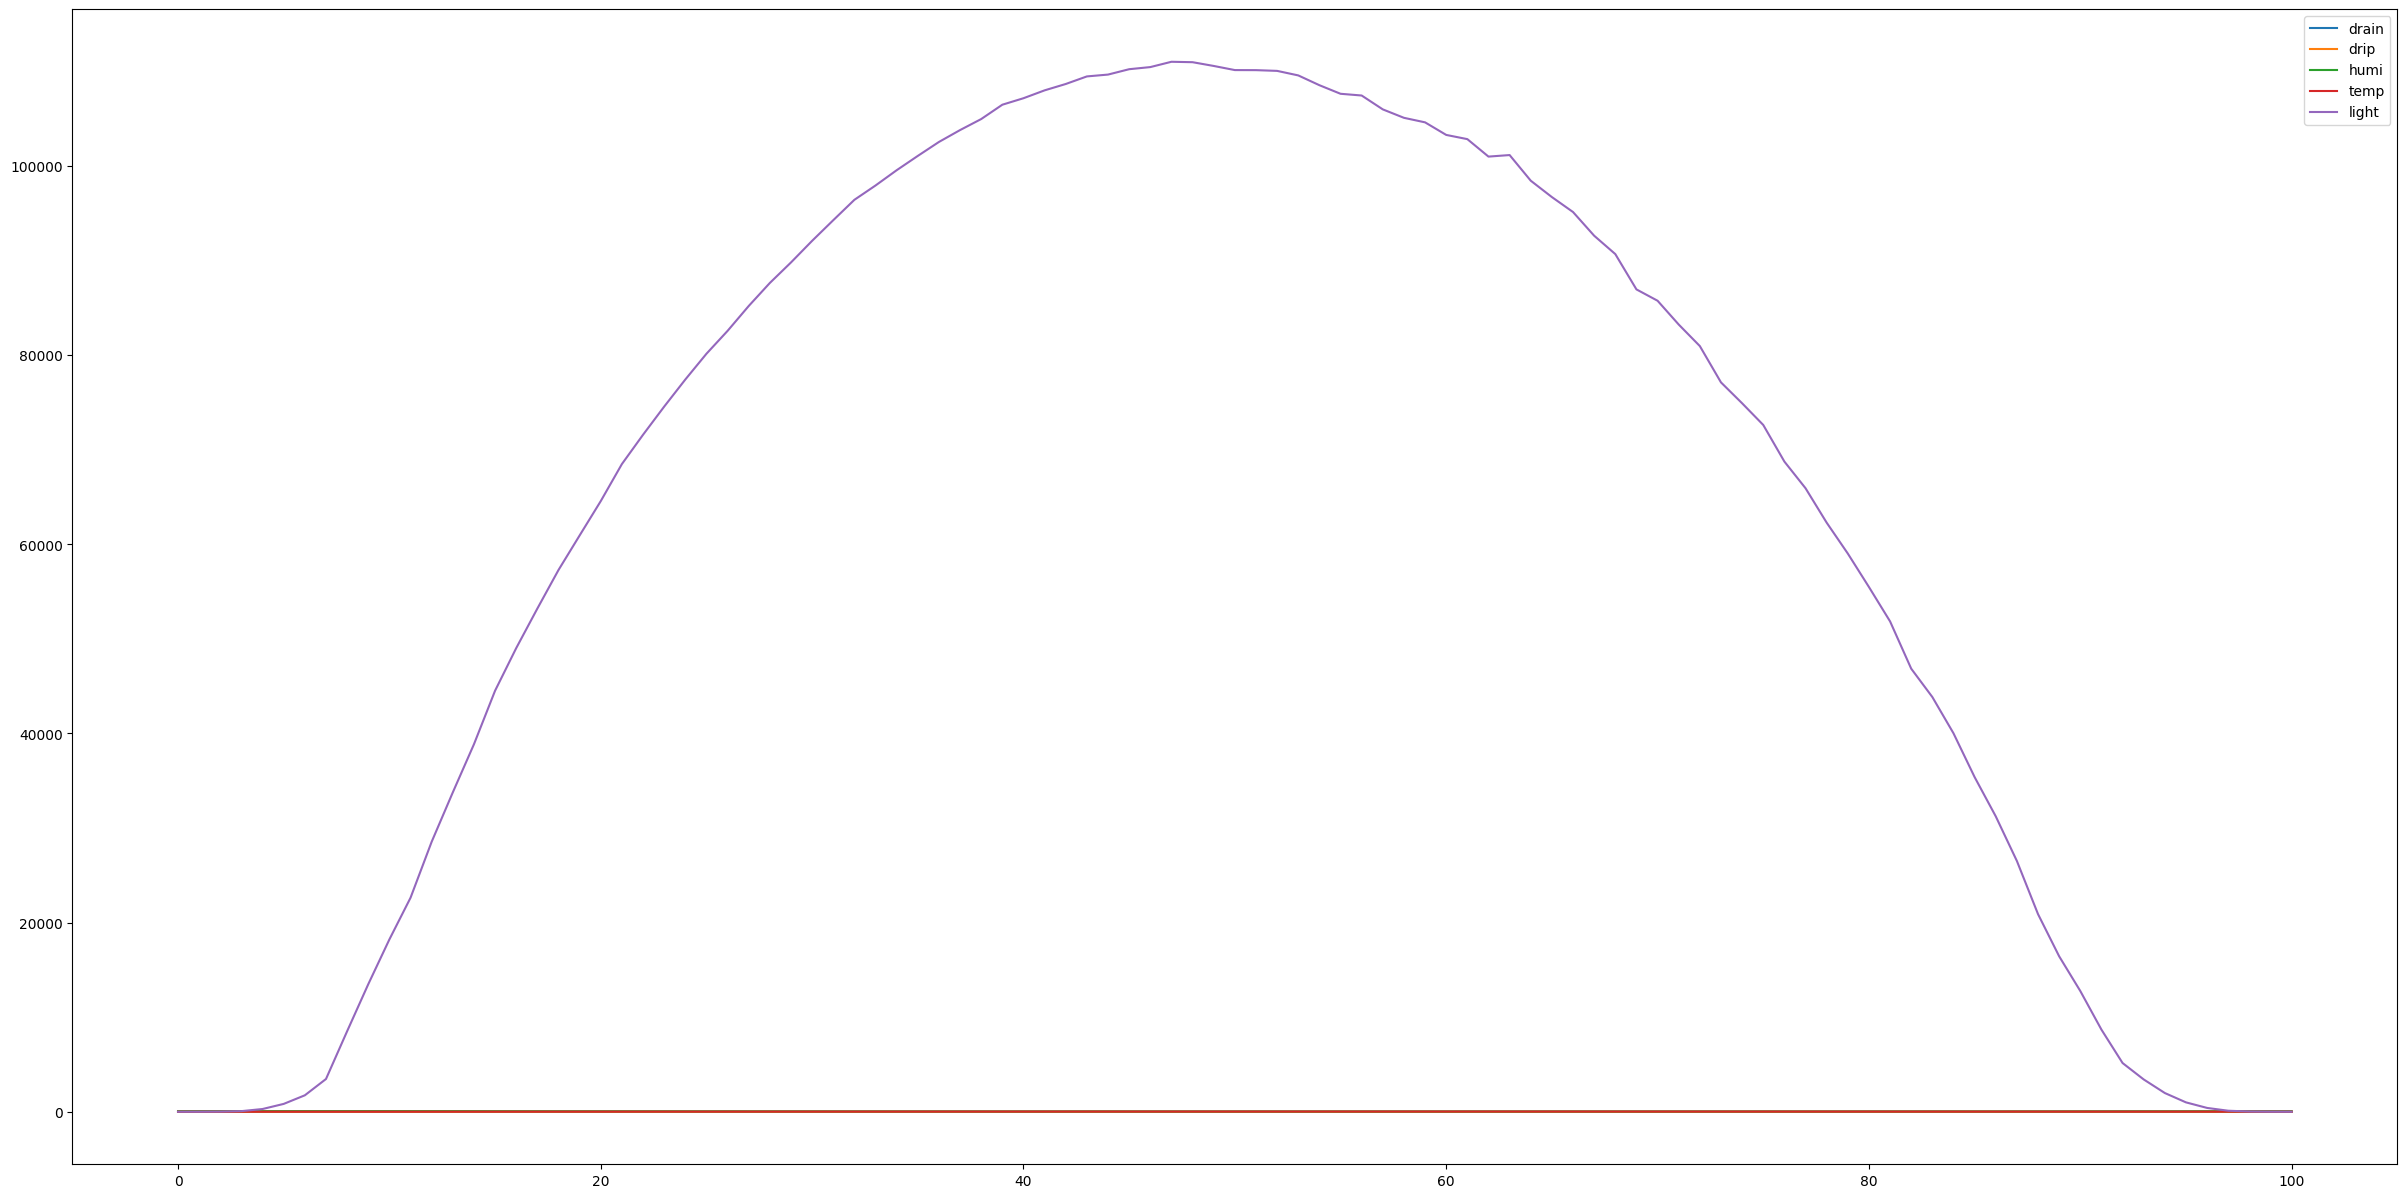

In [79]:
#returns tupels of start, irrigation Point and end of episode in one day
def find_episodes(arr):
    list = []
    start, lastEnd = 0,0
    while start < len(arr)-1: # goes over each sample in a day
        sampleToIgnore = 1
        for i in range(sampleToIgnore,len(arr[start:])): #goes from last starting point and checks if a drip is over 0
            element = (arr[start:][i])
            if element > 0:
                for j, subElement in enumerate(arr[start+i:]): #hops over drips that are below a threshold
                    if subElement == 0:
                        if sum(arr[start+i-sampleToIgnore:start+i+j]) < (80/300): # one episodes has at least the sum of 80/300 drip
                            start += i+j
                        # elif start+i <= 20: # one episodes is at least 15 sample/min long
                        #     start += i
                        else:
                            ending = int(start+(i*2)) #200% der eigentlichen zwischen periode
                            ending = min(len(arr),ending) #prevent index bigger than array
                            list.append((lastEnd, start+i, ending)) 
                            lastEnd = start+i
                            start += i+j
                        break
                break 
            elif i == len(arr[start:])-1: #add last array
                list.append((lastEnd, start+i+1, start+i+1))
                start += i
                break
            elif start + i + 1 >= len(arr)-1: #add last array
                list.append((lastEnd, start+i+1, start+i+1))
                start = len(arr)-1
                break
    return list

#Test
day=14
month=6
labels = get_data("70B3D57ED005C6D0", datetime(2023, month, day, 4), datetime(2023, month, day, 23))
labels = downsample_labeled_data(labels, 10)
epis = find_episodes(labels["drip"]["value"])
print(epis)
plt.figure(figsize=(30,15))
for label in labels:
    plt.plot(range(len(labels[label]["value"])),labels[label]["value"],label=label)
for s,irri,end in epis:
    plt.fill_between(range(s,end),np.ones(len(range(s,end)))*100,alpha=0.3)
plt.legend()

In [80]:
def get_episodes_from_day(labeledData, doy=None):
    labeledData = downsample_labeled_data(labeledData, factor=10) #downsample to 10min intervals
    episodes = []
    lengthEpisodes = find_episodes(labeledData["drip"]["value"])
    for start, irri, end in lengthEpisodes[1:-1]: #drop last episode because no action possible, drop first episode because no drain measured
        episode = {}
        episode['doy'] = doy
        episode['abstime'] = []
        episode['time'] = []
        episode['temp'] = []
        episode['humi'] = []
        episode['light'] = []
        episode['drain'] = []
        episode['reward'] = []
        episode['terminal'] = []
        episode['timeToIrri'] = []
        
        # Initialize cumulative sums for temp and humi
        cumsum_temp = 0
        cumsum_humi = 0
        cumsum_light = 0
        
        for i in range(start, end):
            abstime = labeledData["drip"]["time"][i]/60 # in Minuten
            timeToIrri = (labeledData["drip"]["time"][irri] - labeledData["drip"]["time"][i])/60 # in Minuten
            time = (labeledData["drip"]["time"][i] - labeledData["drip"]["time"][start])/60 # in Minuten
            terminal = 1 if timeToIrri <= 0 else 0
            
            # Accumulate drain values (cumulative sum)
            if i == start:
                drain = labeledData["drain"]["value"][i] if timeToIrri > 0 else 0
            else:
                drain = episode['drain'][-1] + (labeledData["drain"]["value"][i] if timeToIrri > 0 else 0)
            
            # Cumulative sums for temp, humi, and light
            cumsum_temp += labeledData["temp"]["value"][i]
            cumsum_humi += labeledData["humi"]["value"][i]
            cumsum_light += lux_to_wm2(labeledData["light"]["value"])[i]
            
            reward = 1  
                       
            episode['abstime'].append(abstime)
            episode['time'].append(time)
            episode['temp'].append(cumsum_temp)
            episode['humi'].append(cumsum_humi)
            episode['light'].append(cumsum_light)
            episode['drain'].append(drain)
            episode['reward'].append(reward)
            episode['terminal'].append(terminal)
            episode['timeToIrri'].append(timeToIrri)
        
        # Convert lists to numpy arrays
        for key in episode:
            if key != 'doy' and isinstance(episode[key], list):
                episode[key] = np.array(episode[key])
        
        episodes.append(episode)
    return episodes

data = get_data("70B3D57ED005C6D0", datetime(2023, 8, 23, 4), datetime(2023, 8, 23, 23))
lengthEpisodes = find_episodes(data["drip"]["value"])
print(lengthEpisodes)
episoden = get_episodes_from_day(data, doy=datetime(2023, 8, 23).timetuple().tm_yday)
print(len(episoden))
for n, epi in enumerate(episoden):
    timeToIrris = []
    # plt.plot(range(len(epi)),data["drip"]["value"][lengthEpisodes[n][0]:lengthEpisodes[n][2]],label="drip")
    # plt.plot(range(len(epi)),data["drain"]["value"][lengthEpisodes[n][0]:lengthEpisodes[n][2]],label="drain")
    # plt.plot(range(len(epi)),[abstime for abstime, time, drain, humi, temp, light, drip, timeToIrri in epi],label="seconds absolut")
    # plt.plot(range(len(epi)),[time for abstime, time, drain, humi, temp, light, drip, timeToIrRi in epi],label="seconds relativ")
    # plt.plot(range(len(epi)),[drain for epiDoy, abstime, time, temp, humi, light, drain, drip, timeToIrRi, terminal in epi],label="drain")
    # plt.plot(range(len(epi)),[drip for epiDoy, abstime, time, temp, humi, light, drain, drip, timeToIrRi, terminal in epi],label="drip")
    # plt.plot(range(len(epi)),[humi for abstime, time, drain, humi, temp, light, drip, timeToIrRi in epi],label="humidity")
    # plt.plot(range(len(epi)),[temp for abstime, time, drain, humi, temp, light, drip, timeToIrRi in epi],label="temperatur")
    # plt.plot(range(len(epi)),[light for abstime, time, drain, humi, temp, light, drip, timeToIrRi in epi],label="light")
    # plt.plot(range(len(epi)),[timeToIrri for abstime, time, drain, humi, temp, light, drip, timeToIrRi in epi],label="seconds to irrigation")
    # plt.legend()
    # plt.show()

[(0, 78, 156), (78, 158, 222), (158, 203, 242), (203, 247, 284), (247, 293, 333), (293, 341, 383), (341, 394, 398), (394, 439, 478), (439, 486, 526), (486, 533, 573), (533, 580, 621), (580, 683, 780), (683, 864, 864)]
11


In [81]:
#month day tuples
dataD0 = [(5,16),(5,17),(5,18),(5,19),(5,20),(5,21),(5,22),(5,23),(5,24),(5,25),(5,26),(5,27),(5,28),(5,29),(5,30),(5,31),
          (6,2),(6,3),(6,14),(6,15),(6,16),(6,17),(6,18),(6,19),(6,20),(6,21),(6,22),(6,23),(6,24),(6,25),(6,26),(6,27),
          (7,6),(7,7),(7,8),(7,9),(7,10),(7,11),(7,15),
          (8,19),(8,20),(8,21),(8,22),(8,23),(8,24),(8,25),(8,26),(8,27),(8,28),(8,29),(8,30),(8,31),
          (9,1),(9,11),(9,12),(9,13),(9,14)]
dataD0problem = [(6,4),(6,5),(6,6),(6,8),(6,28),(6,29),(6,30),(7,1),(7,2),(7,3),(7,4),(7,5),(7,12),(7,13),(7,14),(7,16),(7,24),
                 (7,25),(7,26),(7,27),(7,28),(7,29),(9,2),(9,3),(9,4),(9,5),(9,6),(9,8),(9,9),(9,10),(9,15),(9,16),(9,17),(9,18)]
dataD2 = [(5,16),(5,17),(5,18),(5,19),(5,20),(5,21),(5,22),(5,23),(5,24),(5,25),(5,28),(6,7),(6,8),(7,8)]
dataD2problem = [(5,26),(5,27),(5,29),(5,30),(5,31),(6,2),(6,3),(6,4),(6,5),(6,6)]

#wechseln von Drip und Drain
dataD1 = [(6,23),(6,24),(6,25),(6,26),(7,6),(7,7),(7,9),(7,10),(7,11),(7,15),(7,16),(7,25),(7,26),(7,27),(7,28),(8,19)]
dataD1problem = [(6,27),(6,28),(6,29),(8,20),(8,21),(8,22),(8,23),(9,8),(9,9),(9,10),(9,11),(9,12),(9,13),(9,14),(9,15)]

#create data tuples
data = [("70B3D57ED005C6D0", dataD0, dataD0problem), ("70B3D57ED005C6D1", dataD1, dataD1problem), ("70B3D57ED005C6D2", dataD2, dataD2problem)]

In [82]:
#save Episodes from data
def save_Episode(baseFolder, month, day, episodes):
    if not os.path.exists(baseFolder):
        os.makedirs(baseFolder)

    for i, episode in enumerate(episodes):
        fileName = os.path.join(baseFolder, f"{month}-{day}-Epi{i}.csv")
        with open(fileName, "w", newline="") as file:
            writer = csv.writer(file)
            # Add header row to match creatEpis format
            header = ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain', 'timeToIrri', 'reward', 'terminal']
            writer.writerow(header)
            
            for j in range(len(episode['time'])):
                observation = [
                    episode['doy'],
                    episode['abstime'][j],
                    episode['time'][j],
                    episode['temp'][j],
                    episode['humi'][j],
                    episode['light'][j],
                    episode['drain'][j],
                    episode['timeToIrri'][j],
                    episode['reward'][j],
                    episode['terminal'][j]
                ]
                writer.writerow(observation)
            
def read_Episodes(baseFolder):
    episodes = []
    for filename in sorted(os.listdir(baseFolder)):
        filePath = os.path.join(baseFolder, filename)
        episode = []
        with open(filePath, "r", newline="") as file:
            reader = csv.reader(file)
            for row in reader:
                observation = [float(epi) for epi in row]
                episode.append(tuple(observation))
            episodes.append(episode)        
    return episodes

# Test
# save_Episode("firstTrue", 8, 23, episoden)
# a  = read_Episodes("firstTrue")
# for i, epsi in enumerate(a):
#     print(epsi)
#     print(epis[i])

In [83]:
savePath = "../episFormula/4 cumsum measured"
data = [("70B3D57ED005C6D0", dataD0, dataD0problem)]
for id,good,bad in data:
    for month, day in good:
        dayData = get_data(id, datetime(2023, month, day, 4), datetime(2023, month, day, 23))
        episodes = get_episodes_from_day(dayData, doy=datetime(2023, month, day).timetuple().tm_yday)
        save_Episode(savePath, month, day, episodes)

In [ ]:
#get mean Drip
meanDrip = []
for id,good,bad in [("70B3D57ED005C6D0", dataD0, dataD0problem)]:
    for month, day in good:
        dayData = get_data(id, datetime(2023, month, day, 4), datetime(2023, month, day, 23))
        epis = find_episodes(dayData["drip"]["value"])
        waterGiven = (dayData['drip']['value'].sum()/300)*8 # /300 um scalierung rückgängig zu machen * 8 wegen 8 tropfern
        drip = waterGiven/(len(epis)-1) # -1 weil letzte epi kein drain gemessen wurde
        meanDrip.append(drip)
plt.figure(figsize=(10,5))
plt.xlabel("Tage")
plt.ylabel("Durchschnittliche Wassermenge pro Episode (l)")
plt.plot(np.arange(len(meanDrip)), meanDrip)
plt.legend()
plt.show()
plt.hist(meanDrip, bins=20)
plt.title("Verteilung der durchschnittlichen Wassermenge pro Episode")
meanDrip = np.mean(meanDrip)
print("Mean drip: ", meanDrip, "l")

In [ ]:
# Anzahl der Episoden
values = [
    len(os.listdir(savePath+"/70B3D57ED005C6D0")),
    len(os.listdir(savePath+"/70B3D57ED005C6D1")),
    len(os.listdir(savePath+"/70B3D57ED005C6D2")),
]
names = ["D0","D1","D2"]


# Creating autopct arguments
def getPct(pct, allvalues):
    absoluteVal = int(pct / 100.0 * np.sum(allvalues))
    return "{:.1f}%\n{:d} Episodes".format(pct, absoluteVal)


# Create a pieplot
plt.pie(
    values,
    labels=names,
    labeldistance=1.15,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
    autopct=lambda pct: getPct(pct, values),
)
plt.title("Distribution within the Database")
plt.show()

In [ ]:
#episoden Länge
data = [("70B3D57ED005C6D0", dataD0, dataD0problem), ("70B3D57ED005C6D1", dataD1, dataD1problem), ("70B3D57ED005C6D2", dataD2, dataD2problem)]
epis = []
for id,good,bad in data:
    for month, day in good:
        dayData = get_data(id, datetime(2023, month, day, 4), datetime(2023, month, day, 23))
        epi = get_episodes_from_day(dayData)
        for e in epi:
            epis.append(len(e))

plt.plot(labels[label]["time"],labels[label]["value"],label=label)
plt.legend()
import numpy as np
import matplotlib.pyplot as plt

def create_bar_chart_with_trend(array):
    unique_values, value_counts = np.unique(array, return_counts=True)
    
    # Erstelle das Balkendiagramm
    plt.bar(unique_values, value_counts, color='b', alpha=0.7, label='Häufigkeit')

    # Berechne die Ausgleichskurve (linear)
    z = np.polyfit(unique_values, value_counts, 10)
    p = np.poly1d(z)
    
    # Zeichne die Ausgleichskurve
    plt.plot(unique_values, p(unique_values), 'r--', label='Ausgleichskurve')

    plt.xlabel('Wert')
    plt.ylabel('Häufigkeit')
    plt.title('Episodenlänge mit Ausgleichskurve')
    plt.legend()
    plt.show()

# Beispielarray
create_bar_chart_with_trend(epis)

In [ ]:
import os
import matplotlib.pyplot as plt
from datetime import datetime

# Ordner zum Speichern der Plots
output_dir = os.path.join("..", "plots", "episoden_d0")
os.makedirs(output_dir, exist_ok=True)

# Iteriere über alle Tage in dataD0
for month, day in dataD0:
    # Hole die Daten für den Tag
    dayData = get_data("70B3D57ED005C6D0", datetime(2023, month, day, 4), datetime(2023, month, day, 23))
    episoden = get_episodes_from_day(dayData)
    # Iteriere über alle Episoden des Tages
    for epi_idx, epi in enumerate(episoden):
        # Drip- und Drain-Werte extrahieren
        drip = [obs[6] for obs in epi]
        drain = [obs[2] for obs in epi]
        x = list(range(len(epi)))
        plt.figure(figsize=(10,5))
        plt.plot(x, drip, label="Drip")
        plt.plot(x, drain, label="Drain")
        plt.xlabel("Timestep")
        plt.ylabel("Normierter Wert")
        plt.title(f"Tag: {day}.{month} - Episode {epi_idx+1}")
        plt.legend()
        plt.show()